# Analysis of the Reconstructed Matrices

In [ ]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


# Step 1: Load Full Reconstructed Dataset (Local PC)
Load reconstructed matrices.

In [ ]:
DATASET_NAME = 'data_00_20_w724_s10'
FILE_NAME = 'all_reconstructed_linearAE_005.pt'

project_root = Path.cwd().resolve().parent
base_dir = project_root / 'data' / 'processed' / 'dataset'
dataset_dir = base_dir / DATASET_NAME

ALL_RECONSTRUCTED_MATRIX_FILE = dataset_dir / FILE_NAME
RESULTS_FOLDER = project_root / 'results' / f'{FILE_NAME}' / 'reconstruction_analysis'
RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)

if not ALL_RECONSTRUCTED_MATRIX_FILE.exists():
    raise FileNotFoundError(
        f"File '{ALL_RECONSTRUCTED_MATRIX_FILE.name}' not found in: {dataset_dir.absolute()}"
    )

print(f'Dataset selected: {DATASET_NAME}')
print(f'All Reconstructed Matrix: {ALL_RECONSTRUCTED_MATRIX_FILE.name}')

Dataset selected: data_00_20_w724_s10
All Reconstructed Matrix: all_reconstructed_linearAE_005.pt


In [11]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')
    corr_tensor = payload.get('corr_tensor', None)
    recon_tensor = payload.get('corr_tensor_reconstructed', None)
    indices = payload.get('indices', None)
    meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')
    if recon_tensor is None:
        raise KeyError('corr_tensor_reconstructed key not found in .pt file')
    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')
    if recon_tensor.ndim != 3 or recon_tensor.shape[1] != recon_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor_reconstructed: {recon_tensor.shape}')

    return corr_tensor.float(), recon_tensor.float(), indices, meta


gt_corr, recon_corr, indices, meta = load_corr_payload(ALL_RECONSTRUCTED_MATRIX_FILE)

print(f'Ground truth correlation tensor shape: {gt_corr.shape}')
print(f'Reconstructed correlation tensor shape: {recon_corr.shape}')
print(f'Indices: {indices[:10]}')
print(f'Metadata keys: {list(meta.keys())}')
print(gt_corr[:1,:5,:5])
print(recon_corr[:1,:5,:5])

Ground truth correlation tensor shape: torch.Size([412, 362, 362])
Reconstructed correlation tensor shape: torch.Size([412, 362, 362])
Indices: [49, 50, 51, 52, 53, 54, 55, 56, 57, 58]
Metadata keys: ['indices', 'split', 'meta', 'corr_tensor_reconstructed']
tensor([[[1.0000, 0.1305, 0.1530, 0.2544, 0.4250],
         [0.1305, 1.0000, 0.1224, 0.3038, 0.1635],
         [0.1530, 0.1224, 1.0000, 0.1499, 0.2088],
         [0.2544, 0.3038, 0.1499, 1.0000, 0.2217],
         [0.4250, 0.1635, 0.2088, 0.2217, 1.0000]]])
tensor([[[0.8124, 0.2094, 0.2340, 0.2101, 0.3013],
         [0.2125, 0.7667, 0.1785, 0.2375, 0.1749],
         [0.1788, 0.1856, 0.8463, 0.2609, 0.2713],
         [0.2061, 0.2639, 0.1971, 0.8735, 0.3032],
         [0.3189, 0.2817, 0.2321, 0.2207, 0.8040]]])


In [28]:
SAMPLE_IDX = 49
if SAMPLE_IDX not in indices:
    raise ValueError(f'SAMPLE_IDX {SAMPLE_IDX} not found in indices list')

orig_mat = gt_corr[SAMPLE_IDX].detach().cpu().numpy()
recon_mat = recon_corr[SAMPLE_IDX].detach().cpu().numpy()
err_mat = recon_mat - orig_mat

print(f'Sample index: {SAMPLE_IDX}\n')
print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((err_mat) ** 2))
mae_sample = float(np.mean(np.abs(err_mat)))
fro_sample = float(np.linalg.norm(err_mat, ord='fro'))


print(f'\nMSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Original Matrix range - Min: {orig_mat.min():.6f} | Max: {orig_mat.max():.6f}')
print(f'Reconstructed Matrix range - Min: {recon_mat.min():.6f} | Max: {recon_mat.max():.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')


Sample index: 49

Original Matrix:
[[1.     0.0807 0.1503 0.1593 0.2778]
 [0.0807 1.     0.1496 0.2186 0.1323]
 [0.1503 0.1496 1.     0.204  0.1445]
 [0.1593 0.2186 0.204  1.     0.1421]
 [0.2778 0.1323 0.1445 0.1421 1.    ]]
Reconstructed Matrix:
[[0.7284 0.1962 0.2321 0.1897 0.2519]
 [0.1995 0.6499 0.1674 0.1875 0.1158]
 [0.1491 0.1785 0.7805 0.2637 0.266 ]
 [0.1863 0.2274 0.1731 0.8208 0.3006]
 [0.2823 0.2688 0.2097 0.1816 0.7125]]
Error Matrix:
[[-0.2716  0.1154  0.0818  0.0304 -0.0259]
 [ 0.1187 -0.3501  0.0177 -0.0311 -0.0166]
 [-0.0013  0.0289 -0.2195  0.0597  0.1215]
 [ 0.0269  0.0088 -0.0309 -0.1792  0.1585]
 [ 0.0045  0.1365  0.0651  0.0395 -0.2875]]

MSE: 0.008692 | MAE: 0.072945 | Frobenius: 33.750393
Original Matrix range - Min: -0.105261 | Max: 1.000000
Reconstructed Matrix range - Min: -0.085849 | Max: 0.922497
Error range - Min: -0.463778 | Max: 0.497683


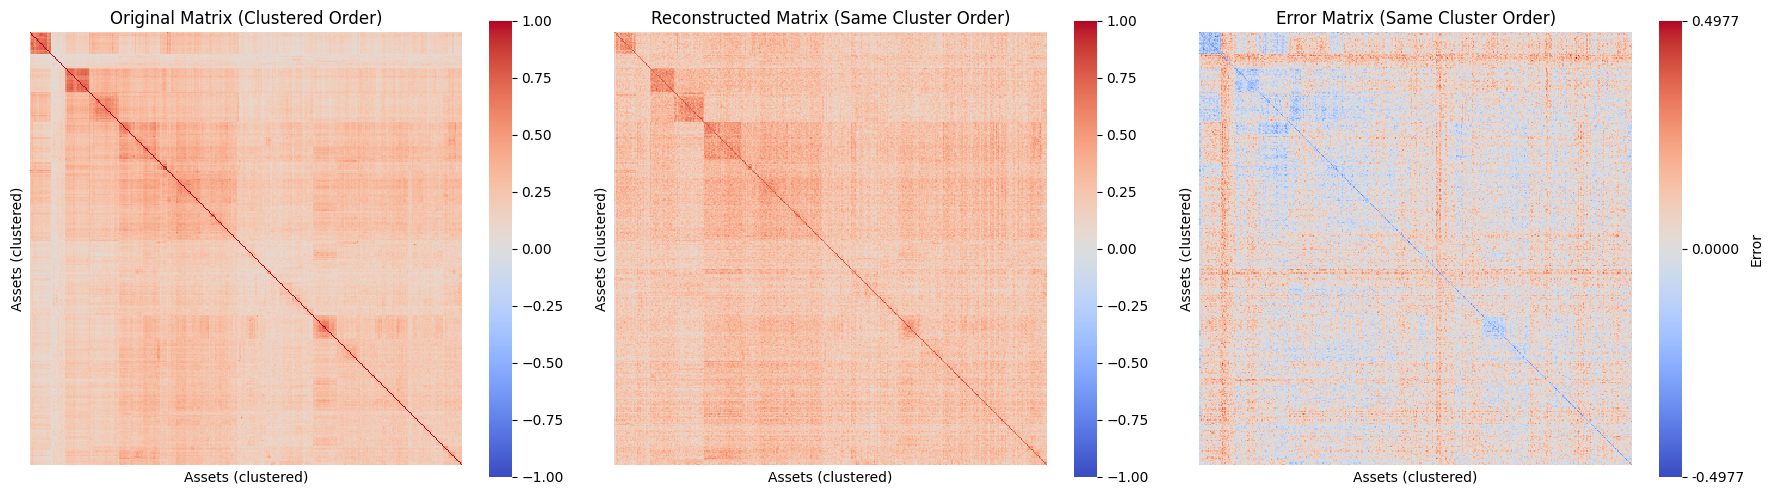

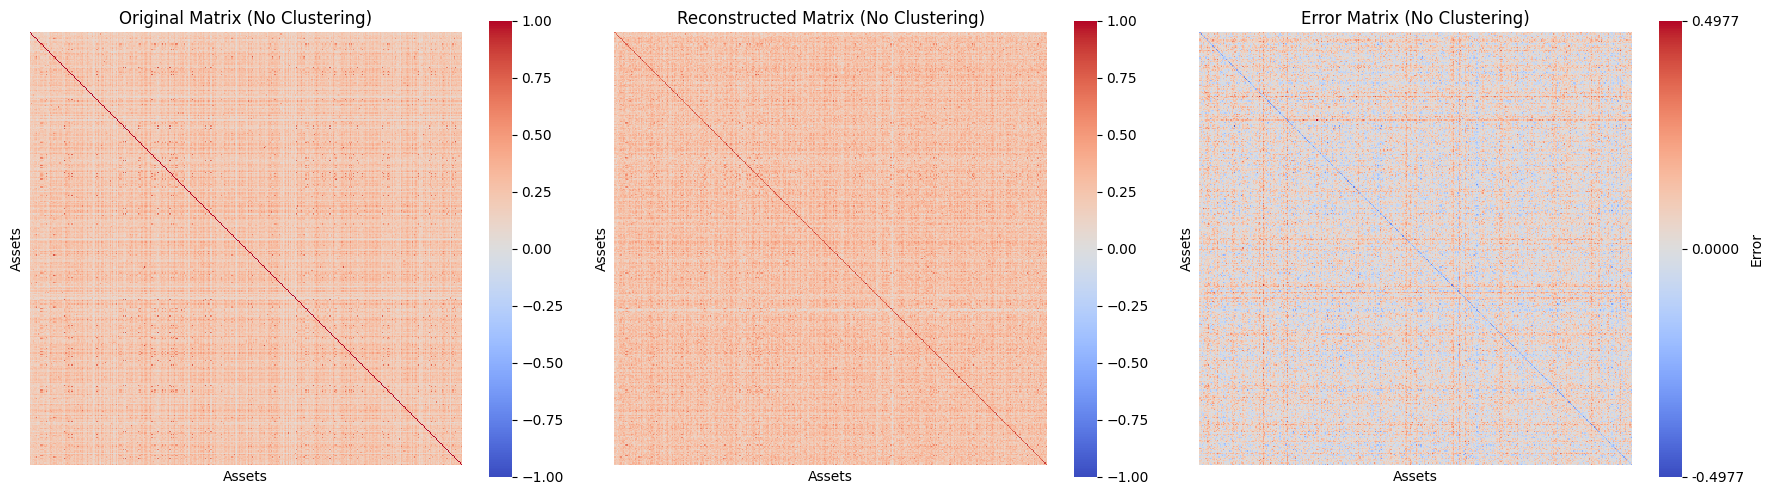

In [ ]:
shared_cmap = 'coolwarm'
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path = RESULTS_FOLDER / 'clustered_heatmaps.png'
fig_cluster.savefig(path, dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(
    err_mat,
    ax=axes[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes[2].set_title('Error Matrix (No Clustering)')

cbar_std = hm.collections[0].colorbar
cbar_std.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_std.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path = RESULTS_FOLDER / 'no_clustered_heatmaps.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()